# Optimization Engine

Three strategies solve the same one-month cargo allocation problem -- how many cargoes to ship from each origin to each destination -- using `src/optimization.py`:

1. **Naive**: each origin ships 100% of its capacity to whichever destination has the higher *headline* price.
2. **Expected-value LP**: maximize expected netback subject to liquefaction/storage/vessel capacity.
3. **Risk-aware LP**: maximize `E[netback] - lambda * CVaR_95(loss)`, same capacity constraints. CVaR via the standard Rockafellar-Uryasev LP formulation.

All three are evaluated against the *same* 2000 simulated one-month-ahead scenarios.

In [1]:
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "../src")
from netback import CostAssumptions
from network_config import DESTINATIONS, ORIGINS, ROUTES, VESSEL
from optimization import (
    clip_to_capacity,
    evaluate_portfolio,
    naive_allocation,
    portfolio_stats,
    scenario_netbacks,
    solve_cvar_lp,
    solve_ev_lp,
)
from simulator import HubParams, simulate_paths

## Generate scenarios (1 month ahead)

In [2]:
with open("../data/processed/calibration/hub_params.json") as f:
    calibration = json.load(f)

hub_order = calibration["correlation"]["hub_order"]
corr_matrix = calibration["correlation"]["matrix"]
all_params = [HubParams(**calibration["primary"][name]) for name in hub_order]

with open("../data/processed/combined/monthly_aligned.csv") as f:
    import csv
    rows = list(csv.DictReader(f))
latest = rows[-1]
start_prices = {
    "HENRY_HUB": float(latest["henry_hub"]),
    "TTF": float(latest["ttf"]),
    "JKM": float(latest["jkm"]),
    "FREIGHT_ATLANTIC": float(latest["freight_atlantic"]),
    "FREIGHT_PACIFIC": float(latest["freight_pacific"]),
}

N_SCENARIOS = 2000
paths = simulate_paths(all_params, corr_matrix, n_paths=N_SCENARIOS, n_steps=1, start_prices=start_prices, seed=7)

scenario_prices = [
    {"HENRY_HUB": paths["HENRY_HUB"][i, -1], "TTF": paths["TTF"][i, -1], "JKM": paths["JKM"][i, -1]}
    for i in range(N_SCENARIOS)
]
scenario_freight = [
    {"FREIGHT_ATLANTIC": paths["FREIGHT_ATLANTIC"][i, -1], "FREIGHT_PACIFIC": paths["FREIGHT_PACIFIC"][i, -1]}
    for i in range(N_SCENARIOS)
]

netbacks = scenario_netbacks(scenario_prices, scenario_freight)
print(f"{N_SCENARIOS} scenarios generated. Mean netback per route (USD/MMBtu):")
for k, v in netbacks.items():
    print(f"  {k}: mean={v.mean():6.2f}  std={v.std():5.2f}")

2000 scenarios generated. Mean netback per route (USD/MMBtu):
  ('US_GC', 'EUROPE'): mean= 15.67  std= 2.89
  ('US_GC', 'ASIA'): mean= 16.19  std= 3.82
  ('US_GC', 'US_DOMESTIC'): mean=  3.04  std= 0.70
  ('QATAR', 'EUROPE'): mean= 15.67  std= 2.89
  ('QATAR', 'ASIA'): mean= 16.50  std= 3.81
  ('AUSTRALIA', 'ASIA'): mean= 16.54  std= 3.81
  ('AUSTRALIA', 'EUROPE'): mean= 15.15  std= 2.89


## Solve all three strategies

In [3]:
naive_raw = naive_allocation(scenario_prices, scenario_freight)
naive_clipped = clip_to_capacity(naive_raw)

ev_alloc, ev_obj, ev_status = solve_ev_lp(netbacks)
assert ev_status == "Optimal", f"EV LP did not solve to optimality: {ev_status}"

RISK_LAMBDA = 2.0  # risk-aversion knob -- would be a dashboard slider; see the sensitivity sweep below for why 2.0
risk_alloc, risk_obj, risk_status = solve_cvar_lp(netbacks, risk_lambda=RISK_LAMBDA, alpha=0.95)
assert risk_status == "Optimal", f"risk-aware LP did not solve to optimality: {risk_status}"

strategies = {"naive (infeasible)": naive_raw, "naive (capacity-clipped)": naive_clipped, "expected-value LP": ev_alloc, "risk-aware LP": risk_alloc}

alloc_df = pd.DataFrame(strategies).fillna(0).round(2)
alloc_df.index = [f"{o}->{d}" for o, d in alloc_df.index]
alloc_df

,naive (infeasible),naive (capacity-clipped),expected-value LP,risk-aware LP
US_GC->ASIA,8.0,3.21,0.00,0.00
QATAR->ASIA,12.0,4.82,8.00,0.34
AUSTRALIA->ASIA,7.0,2.81,7.00,7.00
US_GC->EUROPE,0.0,0.00,0.00,0.00
US_GC->US_DOMESTIC,0.0,0.00,8.00,8.00
QATAR->EUROPE,0.0,0.00,0.62,8.28
AUSTRALIA->EUROPE,0.0,0.00,0.00,0.00


LP's allocation: US Gulf Coast ships **domestically**, not to Europe or Asia, even though export netback is far higher per MMBtu. The vessel fleet (10 vessels, 300 vessel-days/month) is the binding constraint here, and US_GC's routes are expensive (long transits) relative to Qatar's and Australia's short ones.

## Portfolio value comparison

In [4]:
cargo_size = VESSEL["cargo_size_mmbtu"]
stats_rows = {}
portfolio_values = {}
for name, alloc in strategies.items():
    pv = evaluate_portfolio(alloc, netbacks)
    portfolio_values[name] = pv * cargo_size
    stats_rows[name] = portfolio_stats(pv, cargo_size_mmbtu=cargo_size)

stats_df = pd.DataFrame(stats_rows).T
for col in stats_df.columns:
    stats_df[col] = stats_df[col].apply(lambda v: f"${v:,.0f}")
stats_df

,mean,std,min,max,VaR95,CVaR95,sharpe_like,worst_case_shortfall_pct
naive (infeasible),"$1,329,953,759","$308,851,562","$539,446,916","$2,831,737,204","$872,579,074","$794,038,528",$4,$59
naive (capacity-clipped),"$534,117,975","$124,036,772","$216,645,348","$1,137,243,857","$350,433,363","$318,890,975",$4,$59
expected-value LP,"$845,499,643","$177,546,144","$387,244,385","$1,681,331,646","$581,825,391","$537,952,736",$5,$54
risk-aware LP,"$826,446,492","$147,425,938","$445,134,208","$1,415,090,955","$606,697,860","$563,481,064",$6,$46


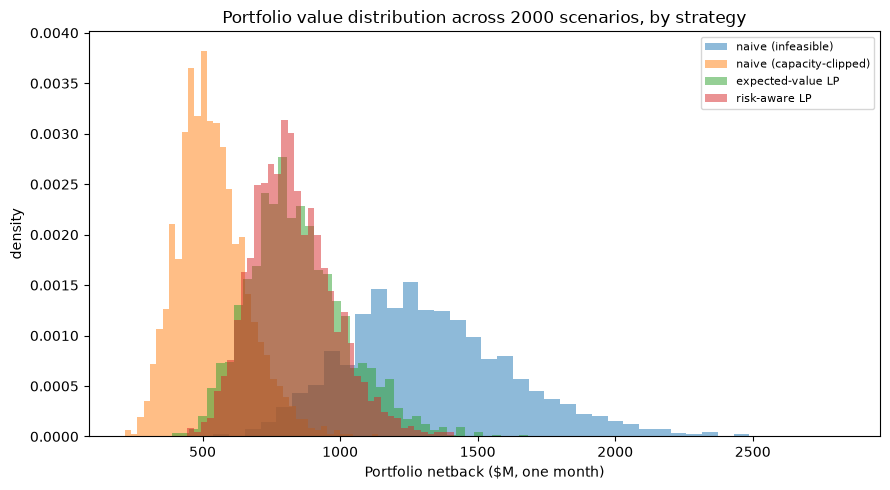

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, pv in portfolio_values.items():
    ax.hist(pv / 1e6, bins=40, alpha=0.5, label=name, density=True)
ax.set_xlabel("Portfolio netback ($M, one month)")
ax.set_ylabel("density")
ax.set_title("Portfolio value distribution across 2000 scenarios, by strategy")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Why naive fails

In [6]:
from optimization import round_trip_days

route_by_key = {(r.origin, r.destination): r for r in ROUTES}
demand_by_dest = {}
for (o, d), qty in naive_raw.items():
    demand_by_dest[d] = demand_by_dest.get(d, 0) + qty
print("Naive demand vs. storage capacity, by destination:")
for d, cfg in DESTINATIONS.items():
    demand = demand_by_dest.get(d, 0)
    flag = "  <-- OVERSUBSCRIBED" if demand > cfg.storage_capacity_cargoes else ""
    print(f"  {d:<12} demand={demand:5.1f} cargoes   capacity={cfg.storage_capacity_cargoes:5.1f}{flag}")

vessel_days_needed = sum(qty * round_trip_days(route_by_key[k]) for k, qty in naive_raw.items() if route_by_key[k].requires_vessel)
vessel_days_available = VESSEL["fleet_size_vessels"] * 30
print(f"\nNaive vessel-days needed: {vessel_days_needed:.0f} vs. available: {vessel_days_available:.0f}"
      f"{'  <-- OVERSUBSCRIBED' if vessel_days_needed > vessel_days_available else ''}")

raw_mean = stats_rows["naive (infeasible)"]["mean"]
clipped_mean = stats_rows["naive (capacity-clipped)"]["mean"]
lost_pct = (1 - clipped_mean / raw_mean) * 100
print(f"\nThe naive rule's theoretical value (${raw_mean:,.0f}) assumes cargoes that physically cannot move; "
      f"once clipped to what capacity actually allows, realized value drops by {lost_pct:.0f}% "
      f"(to ${clipped_mean:,.0f}).")

Naive demand vs. storage capacity, by destination:
  EUROPE       demand=  0.0 cargoes   capacity= 15.0
  ASIA         demand= 27.0 cargoes   capacity= 15.0  <-- OVERSUBSCRIBED
  US_DOMESTIC  demand=  0.0 cargoes   capacity= 20.0

Naive vessel-days needed: 747 vs. available: 300  <-- OVERSUBSCRIBED

The naive rule's theoretical value ($1,329,953,759) assumes cargoes that physically cannot move; once clipped to what capacity actually allows, realized value drops by 60% (to $534,117,975).


## Risk-aversion sensitivity: the mean-CVaR efficient frontier

Sweep `risk_lambda` from 0 upward and trace out the tradeoff between expected value and downside protection

 lambda        mean      CVaR95
   0.00 845,499,643 537,952,736
   0.25 845,499,643 537,952,736
   0.50 845,223,277 538,519,205
   0.75 834,076,374 556,914,747
   1.00 831,446,312 559,933,438
   1.50 828,627,633 562,288,615
   2.00 826,446,492 563,481,064
   3.00 825,601,402 563,880,100
   5.00 825,601,402 563,880,100


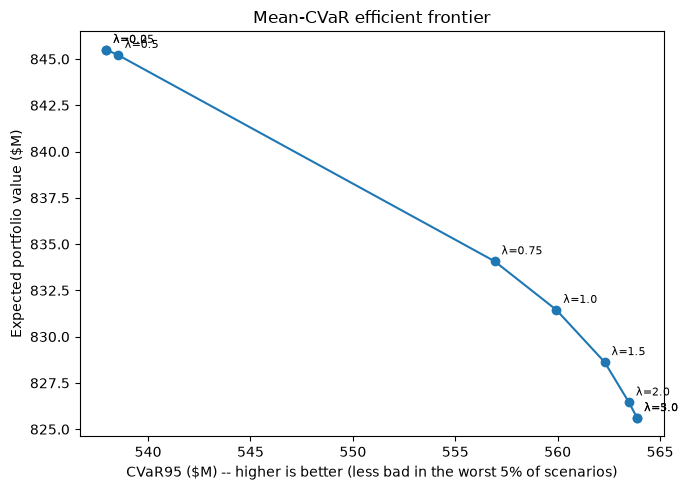

In [7]:
lambdas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
frontier = []
for lam in lambdas:
    alloc, _, status = solve_cvar_lp(netbacks, risk_lambda=lam, alpha=0.95)
    assert status == "Optimal", f"lambda={lam} did not solve to optimality: {status}"
    pv = evaluate_portfolio(alloc, netbacks) * cargo_size
    stats = portfolio_stats(pv / cargo_size, cargo_size_mmbtu=cargo_size)
    frontier.append({"lambda": lam, "mean": stats["mean"], "CVaR95": stats["CVaR95"]})

frontier_df = pd.DataFrame(frontier)
print(frontier_df.to_string(index=False, float_format=lambda x: f"{x:,.0f}" if abs(x) > 10 else f"{x:.2f}"))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(frontier_df["CVaR95"] / 1e6, frontier_df["mean"] / 1e6, "o-")
for _, row in frontier_df.iterrows():
    ax.annotate(f"λ={row['lambda']}", (row["CVaR95"] / 1e6, row["mean"] / 1e6), fontsize=8, textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("CVaR95 ($M) -- higher is better (less bad in the worst 5% of scenarios)")
ax.set_ylabel("Expected portfolio value ($M)")
ax.set_title("Mean-CVaR efficient frontier")
fig.tight_layout()
plt.show()

## Save

In [8]:
import os

os.makedirs("../data/processed/optimization", exist_ok=True)
alloc_df.to_csv("../data/processed/optimization/allocations.csv")
frontier_df.to_csv("../data/processed/optimization/risk_frontier.csv", index=False)
with open("../data/processed/optimization/portfolio_stats.json", "w") as f:
    json.dump(stats_rows, f, indent=2)

print("Saved allocations.csv, risk_frontier.csv, portfolio_stats.json to ../data/processed/optimization/")

Saved allocations.csv, risk_frontier.csv, portfolio_stats.json to ../data/processed/optimization/
